0.017234666524290357
High current fit parameters: n = 2.6787 ± 0.0041, Is = 9.9402e-06 ± 1.6027e-07, Rs = 2.9886e-01 ± 3.4498e-11
High current R-squared: 0.9844


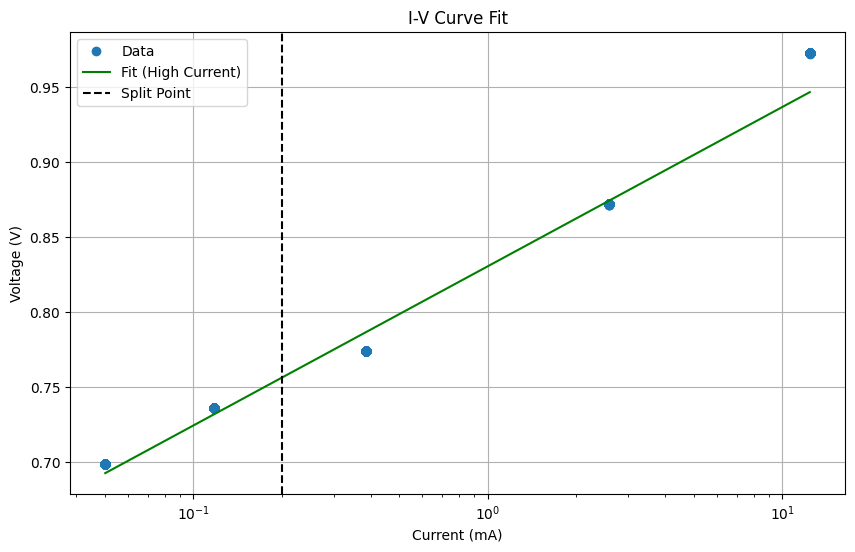

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit, fsolve
from dataclasses import dataclass, field
from typing import Optional
import warnings

df = pd.read_csv("time_series_single_states.csv")

k_B = 1.380649e-23   # Boltzmann constant [J/K]
q   = 1.602176634e-19 # Elementary charge [C]
Tref = 200 # reference temperature, K
V_T = k_B * Tref / q # reference voltage
Is = 1e-10
print(V_T)

def iv_curve(I, n, Is, Rs):
    # return a*np.log(I) + b
    return n*V_T*(np.log(I/Is))+Rs

# Split the data at current = 0.2
df_low = df[df['current_mA'] <= 0.2]
df_high = df[df['current_mA'] > 0.0]

# Fit for low current region
# Define bounds for the parameters
bounds_low = ([0, 1e-20, 0], [5, 1e-5, 50])
bounds_high = ([0, 1e-20, 0], [5, 1e-5, 50])

# Fit for low current region with bounds
#popt_low, pcov_low = curve_fit(iv_curve, df_low['current_mA'], df_low['fv2'], bounds=bounds_low)

# Fit for high current region with bounds
popt_high, pcov_high = curve_fit(iv_curve, df_high['current_mA'], df_high['fv2'], bounds=bounds_high)

# Generate fit data points
# I_fit_low = np.logspace(np.log10(df_low['current_mA'].min()), np.log10(0.2), 50)
# V_fit_low = iv_curve(I_fit_low, *popt_low)

I_fit_high = np.logspace(np.log10(df_high['current_mA'].min()), np.log10(df_high['current_mA'].max()), 50)
V_fit_high = iv_curve(I_fit_high, *popt_high)

# Plot
plt.figure(figsize=(10, 6))
plt.semilogx(df['current_mA'], df['fv2'], 'o', label='Data')
# plt.semilogx(I_fit_low, V_fit_low, 'r-', label='Fit (Low Current)')
plt.semilogx(I_fit_high, V_fit_high, 'g-', label='Fit (High Current)')
plt.axvline(x=0.2, color='k', linestyle='--', label='Split Point')
plt.legend()
plt.xlabel('Current (mA)')
plt.ylabel('Voltage (V)')
plt.title('I-V Curve Fit')
plt.grid(True)

# Calculate R-squared for both regions
def calculate_r_squared(df, popt):
    residuals = df['fv2'] - iv_curve(df['current_mA'], *popt)
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((df['fv2'] - np.mean(df['fv2']))**2)
    return 1 - (ss_res / ss_tot)

# r_squared_low = calculate_r_squared(df_low, popt_low)
r_squared_high = calculate_r_squared(df_high, popt_high)

# Calculate standard errors of the parameters
# perr_low = np.sqrt(np.diag(pcov_low))
perr_high = np.sqrt(np.diag(pcov_high))

# Write out the parameters from the fit, including errors and R-squared
# print(f"Low current fit parameters: n = {popt_low[0]:.4f} ± {perr_low[0]:.4f}, Is = {popt_low[1]:.4e} ± {perr_low[1]:.4e}, Rs = {popt_high[2]:.4e} ± {perr_high[2]:.4e}")
# print(f"Low current R-squared: {r_squared_low:.4f}")
print(f"High current fit parameters: n = {popt_high[0]:.4f} ± {perr_high[0]:.4f}, Is = {popt_high[1]:.4e} ± {perr_high[1]:.4e}, Rs = {popt_high[2]:.4e} ± {perr_high[2]:.4e}")
print(f"High current R-squared: {r_squared_high:.4f}")

plt.show()


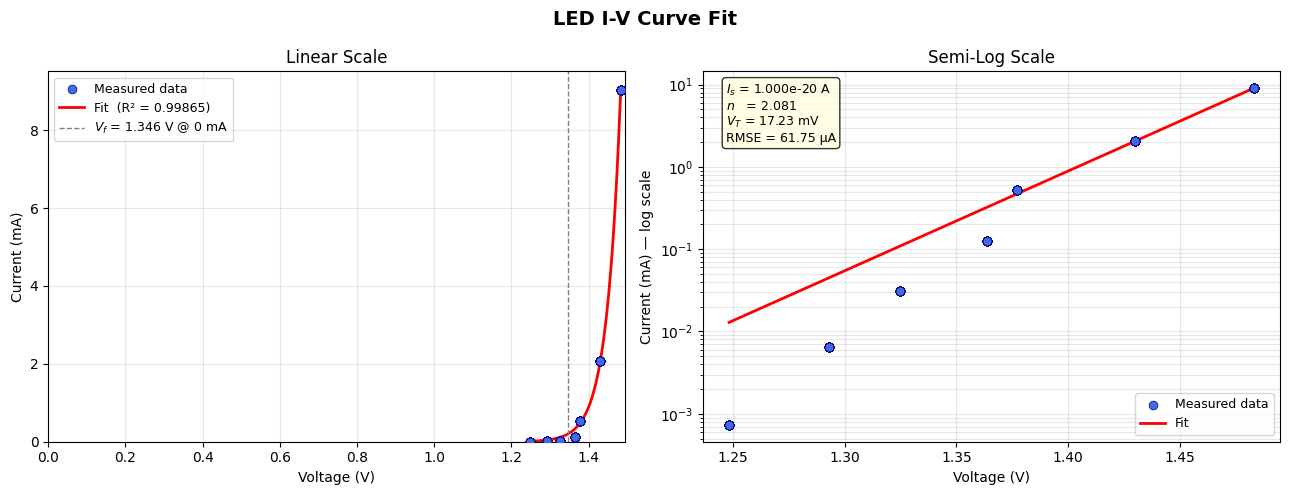


  LED I-V Fit Results (ideal model)
  Temperature        : 200.0 K  (-73.1 °C)
  Thermal voltage    : 17.235 mV
  Saturation current : 1.0000e-20 A
  Ideality factor    : 2.0814
  Forward voltage    : 1.3465 V  @ I = 0.2 mA



In [ ]:
def shockley_ideal(V: np.ndarray, I_s: float, n: float, V_T: float) -> np.ndarray:
    """Ideal Shockley diode: I = I_s * (exp(V / (n*V_T)) - 1)"""
    exponent = np.clip(V / (n * V_T), -500, 500)
    return I_s * (np.exp(exponent) - 1.0)


def shockley_with_rs(V: np.ndarray, I_s: float, n: float, Rs: float, V_T: float) -> np.ndarray:
    """
    Shockley diode with series resistance.
    Solves implicitly: I = I_s * (exp((V - I*Rs) / (n*V_T)) - 1)
    """
    I_out = np.zeros_like(V, dtype=float)
    for i, v in enumerate(V):
        def residual(I_guess):
            exp_arg = np.clip((v - I_guess * Rs) / (n * V_T), -500, 500)
            return I_guess - I_s * (np.exp(exp_arg) - 1.0)
        # Initial guess: ideal model solution
        I_init = max(I_s * (np.exp(np.clip(v / (n * V_T), -500, 500)) - 1.0), 1e-20)
        try:
            I_out[i] = fsolve(residual, I_init, full_output=False)[0]
        except Exception:
            I_out[i] = I_init
    return I_out


def forward_voltage(I_f: float, I_s: float, n: float, Rs: float, V_T: float) -> float:
    """Compute forward voltage at a given current."""
    V_ideal = n * V_T * np.log(I_f / I_s + 1.0)
    return V_ideal + I_f * Rs

@dataclass
class LEDFitResult:
    I_s:     float          # Saturation current [A]
    n:       float          # Ideality factor
    Rs:      float          # Series resistance [Ohm]
    V_T:     float          # Thermal voltage [V]
    T_K:     float          # Temperature [K]
    V_f:     float          # Forward voltage at I_f [V]  (computed)
    I_f:     float          # Reference forward current [A]
    r_cov:   np.ndarray     # Covariance matrix of fitted params
    model:   str            # 'ideal' or 'series_resistance'

    def print_summary(self):
        print("\n" + "="*50)
        print(f"  LED I-V Fit Results ({self.model} model)")
        print("="*50)
        print(f"  Temperature        : {self.T_K:.1f} K  ({self.T_K - 273.15:.1f} °C)")
        print(f"  Thermal voltage    : {self.V_T*1000:.3f} mV")
        print(f"  Saturation current : {self.I_s:.4e} A")
        print(f"  Ideality factor    : {self.n:.4f}")
        if self.model == 'series_resistance':
            print(f"  Series resistance  : {self.Rs:.4f} Ohm")
        print(f"  Forward voltage    : {self.V_f:.4f} V  @ I = {self.I_f*1000:.1f} mA")
        print("="*50 + "\n")



def fit_led_iv(
    V_data: np.ndarray,
    I_data: np.ndarray,
    T_K: float = 200.0,
    model: str = 'series_resistance',
    I_ref: float = 20e-3,
    plot: bool = True,
    title: str = "LED I-V Curve Fit"
) -> LEDFitResult:
    """
    Fit an LED I-V curve.

    Parameters
    ----------
    V_data  : array of voltage measurements [V]
    I_data  : array of current measurements [A]
    T_K     : temperature in Kelvin (default 300 K = 27°C)
    model   : 'ideal' or 'series_resistance'
    I_ref   : reference forward current for Vf reporting [A]
    plot    : whether to show the fit plot
    title   : plot title

    Returns
    -------
    LEDFitResult dataclass with all fitted parameters
    """
    V_data = np.asarray(V_data, dtype=float)
    I_data = np.asarray(I_data, dtype=float)

    # Filter out non-positive currents for log-space fitting stability
    mask = I_data > 0
    V_fit = V_data[mask]
    I_fit = I_data[mask]

    V_T = k_B * T_K / q

    # ── Initial guesses ──────────────────────────────────────────────
    # Estimate n and I_s from the log-linear portion of the I-V curve
    if len(V_fit) >= 2:
        # Use middle portion of the curve for initial slope estimate
        mid = len(V_fit) // 2
        dV = V_fit[mid] - V_fit[0]
        dI = np.log(I_fit[mid] + 1e-30) - np.log(I_fit[0] + 1e-30)
        n_init = (dV / dI) / V_T if dV > 0 and dI > 0 else 2.0
        n_init = np.clip(n_init, 1.0, 6.0)
    else:
        n_init = 2.0

    I_s_init = 1e-10
    Rs_init  = 5.0

    # ── Fitting ──────────────────────────────────────────────────────
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        if model == 'ideal':
            def fit_func(V, I_s, n):
                return shockley_ideal(V, I_s, n, V_T)

            p0     = [I_s_init, n_init]
            bounds = ([1e-20, 0.5], [1e-3, 6.0])
            popt, pcov = curve_fit(fit_func, V_fit, I_fit,
                                   p0=p0, bounds=bounds, maxfev=50000)
            I_s_fit, n_fit = popt
            Rs_fit = 0.0

        elif model == 'series_resistance':
            # Two-stage fit: first fit ideal, then refine with Rs
            def fit_func_ideal(V, I_s, n):
                return shockley_ideal(V, I_s, n, V_T)

            try:
                p0_ideal = [I_s_init, n_init]
                popt_ideal, _ = curve_fit(fit_func_ideal, V_fit, I_fit,
                                          p0=p0_ideal,
                                          bounds=([1e-20, 0.5], [1e-3, 6.0]),
                                          maxfev=20000)
                I_s_init2, n_init2 = popt_ideal
            except Exception:
                I_s_init2, n_init2 = I_s_init, n_init

            def fit_func_rs(V, I_s, n, Rs):
                return shockley_with_rs(V, I_s, n, Rs, V_T)

            p0     = [I_s_init2, n_init2, Rs_init]
            bounds = ([1e-20, 0.5, 0.0], [1e-3, 6.0, 500.0])
            popt, pcov = curve_fit(fit_func_rs, V_fit, I_fit,
                                   p0=p0, bounds=bounds, maxfev=50000,
                                   method='trf')
            I_s_fit, n_fit, Rs_fit = popt

        else:
            raise ValueError(f"Unknown model '{model}'. Choose 'ideal' or 'series_resistance'.")

    # ── Compute forward voltage at reference current ─────────────────
    Vf = forward_voltage(I_ref, I_s_fit, n_fit, Rs_fit, V_T)

    # ── Residuals / Goodness of fit ──────────────────────────────────
    if model == 'ideal':
        I_pred = shockley_ideal(V_data, I_s_fit, n_fit, V_T)
    else:
        I_pred = shockley_with_rs(V_data, I_s_fit, n_fit, Rs_fit, V_T)

    residuals  = I_data - I_pred
    ss_res     = np.sum(residuals**2)
    ss_tot     = np.sum((I_data - np.mean(I_data))**2)
    r_squared  = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rmse       = np.sqrt(np.mean(residuals**2))

    # ── Plot ─────────────────────────────────────────────────────────
    if plot:
        V_smooth = np.linspace(V_data.min(), V_data.max(), 500)
        if model == 'ideal':
            I_smooth = shockley_ideal(V_smooth, I_s_fit, n_fit, V_T)
        else:
            I_smooth = shockley_with_rs(V_smooth, I_s_fit, n_fit, Rs_fit, V_T)

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        fig.suptitle(title, fontsize=14, fontweight='bold')

        # ── Linear scale ────────────────────────────────────────────
        ax = axes[0]
        ax.scatter(V_data, I_data * 1e3, color='royalblue', zorder=5,
                   label='Measured data', s=40, edgecolors='navy', linewidths=0.5)
        ax.plot(V_smooth, I_smooth * 1e3, 'r-', linewidth=2,
                label=f'Fit  (R² = {r_squared:.5f})')
        ax.axvline(Vf, color='gray', linestyle='--', linewidth=1,
                   label=f'$V_f$ = {Vf:.3f} V @ {I_ref*1e3:.0f} mA')
        ax.set_xlabel('Voltage (V)')
        ax.set_ylabel('Current (mA)')
        ax.set_title('Linear Scale')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)

        # ── Log scale ───────────────────────────────────────────────
        ax2 = axes[1]
        pos_mask = I_data > 0
        ax2.scatter(V_data[pos_mask], I_data[pos_mask] * 1e3, color='royalblue',
                    zorder=5, label='Measured data', s=40,
                    edgecolors='navy', linewidths=0.5)
        pos_smooth = I_smooth > 0
        ax2.plot(V_smooth[pos_smooth], I_smooth[pos_smooth] * 1e3, 'r-',
                 linewidth=2, label='Fit')
        ax2.set_yscale('log')
        ax2.set_xlabel('Voltage (V)')
        ax2.set_ylabel('Current (mA) — log scale')
        ax2.set_title('Semi-Log Scale')
        ax2.legend(fontsize=9)
        ax2.grid(True, which='both', alpha=0.3)

        # Annotate parameters on the log plot
        param_text = (
            f"$I_s$ = {I_s_fit:.3e} A\n"
            f"$n$   = {n_fit:.3f}\n"
        )
        if model == 'series_resistance':
            param_text += f"$R_s$ = {Rs_fit:.3f} Ω\n"
        param_text += (
            f"$V_T$ = {V_T*1000:.2f} mV\n"
            f"RMSE = {rmse*1e6:.2f} µA"
        )
        ax2.text(0.04, 0.97, param_text, transform=ax2.transAxes,
                 fontsize=9, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

        plt.tight_layout()
        plt.show()

    result = LEDFitResult(
        I_s=I_s_fit, n=n_fit, Rs=Rs_fit, V_T=V_T,
        T_K=T_K, V_f=Vf, I_f=I_ref, r_cov=pcov, model=model
    )
    result.print_summary()
    return result


result_csv = fit_led_iv(df['fv2'], df['current_mA']/1000., T_K=200.0, model='ideal', I_ref=2e-4)